# 🚨 Kredi Kartı Sahtekârlık Tespiti - Isolation Forest Analizi

**Veri Seti:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Yöntem:** Isolation Forest  
**Amaç:** Kredi kartı işlemlerindeki sahtekârlık (anomali) tespiti  

---

**Veri Seti Özellikleri:**
- 284,807 işlem kaydı
- 31 özellik (V1-V28: PCA ile indirgenmiş, Time, Amount, Class)
- Sadece %0.172 oranında sahtekârlık (ciddi dengesizlik var)

**Not:** Bu notebook Google Colab'da çalışacak şekilde tasarlanmıştır.

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Veri setini indirmek için
!pip install opendatasets -q

# sklearn kütüphaneleri
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


## 2. Veri Setinin Yüklenmesi

In [2]:
# Kaggle'dan veri setini indir
import opendatasets as od

od.download('https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')

# CSV dosyasını oku
df = pd.read_csv('creditcardfraud/creditcard.csv')
print(f'Veri seti boyutu: {df.shape}')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: https://www.kaggle.com/gamzedrn
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:00<00:00, 195MB/s]



Veri seti boyutu: (284807, 31)


In [3]:
# Veri setinin ilk satırlarına bakalım
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
# Veri seti hakkında genel bilgi
print('📊 Veri Seti Özeti:')
print(f'Toplam işlem sayısı: {len(df):,}')
print(f'Özellik sayısı: {df.shape[1]}')
print(f'Eksik değer sayısı: {df.isnull().sum().sum()}')
print()
print('Sınıf Dağılımı (Class):')
print(f'  Normal (0): {(df["Class"] == 0).sum():,} ({(df["Class"] == 0).mean()*100:.3f}%)')
print(f'  Sahtekârlık (1): {(df["Class"] == 1).sum():,} ({(df["Class"] == 1).mean()*100:.3f}%)')

📊 Veri Seti Özeti:
Toplam işlem sayısı: 284,807
Özellik sayısı: 31
Eksik değer sayısı: 0

Sınıf Dağılımı (Class):
  Normal (0): 284,315 (99.827%)
  Sahtekârlık (1): 492 (0.173%)


## 3. Keşifçi Veri Analizi (EDA)

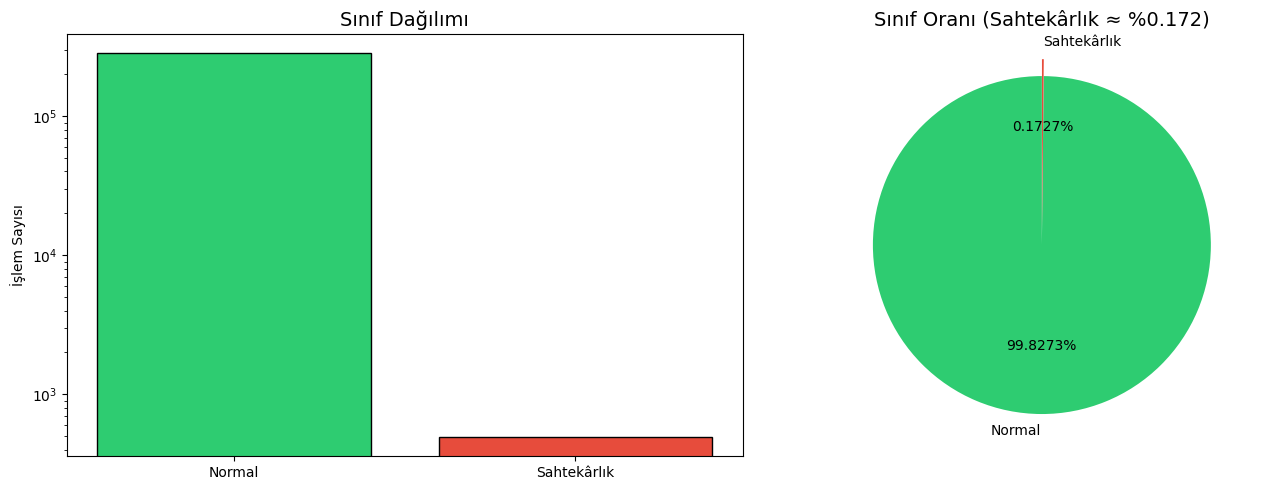


⚠️ Ciddi sınıf dengesizliği var - sahtekârlık çok nadir!


In [5]:
# Sınıf dağılımı grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Class'].value_counts()
axes[0].bar(['Normal', 'Sahtekârlık'], class_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Sınıf Dağılımı', fontsize=14)
axes[0].set_ylabel('İşlem Sayısı')
axes[0].set_yscale('log')

axes[1].pie(class_counts.values, labels=['Normal', 'Sahtekârlık'],
            autopct='%1.4f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Sınıf Oranı (Sahtekârlık ≈ %0.172)', fontsize=14)

plt.tight_layout()
plt.show()
print('\n⚠️ Ciddi sınıf dengesizliği var - sahtekârlık çok nadir!')

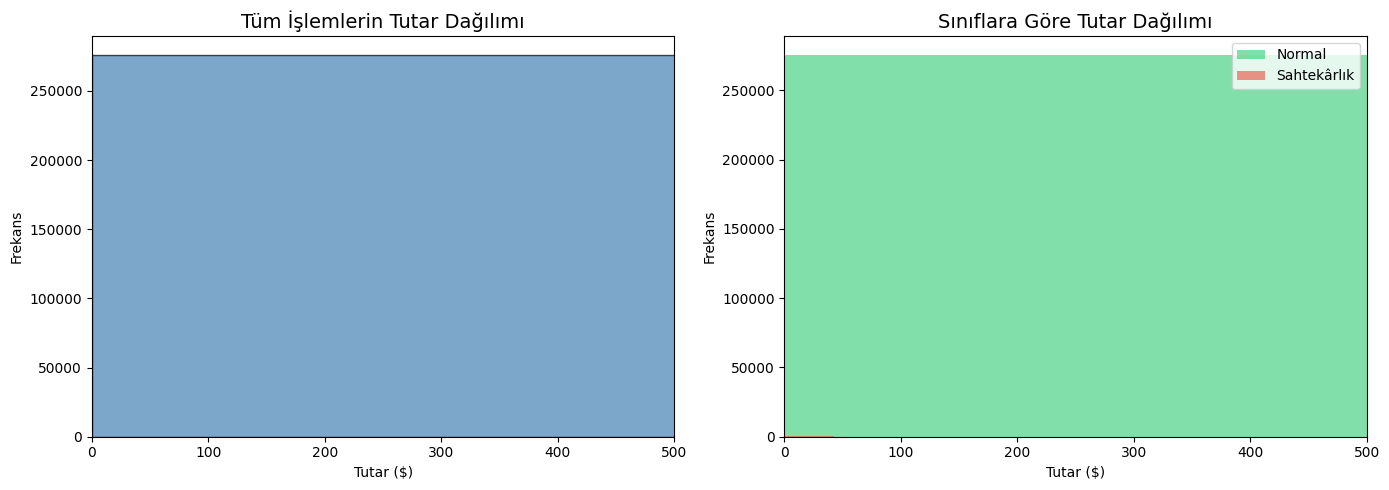

In [6]:
# Transaction Amount (Tutar) dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Tüm İşlemlerin Tutar Dağılımı', fontsize=14)
axes[0].set_xlabel('Tutar ($)')
axes[0].set_ylabel('Frekans')
axes[0].set_xlim([0, 500])

axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             label='Normal', color='#2ecc71')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6,
             label='Sahtekârlık', color='#e74c3c')
axes[1].set_title('Sınıflara Göre Tutar Dağılımı', fontsize=14)
axes[1].set_xlabel('Tutar ($)')
axes[1].set_ylabel('Frekans')
axes[1].set_xlim([0, 500])
axes[1].legend()

plt.tight_layout()
plt.show()

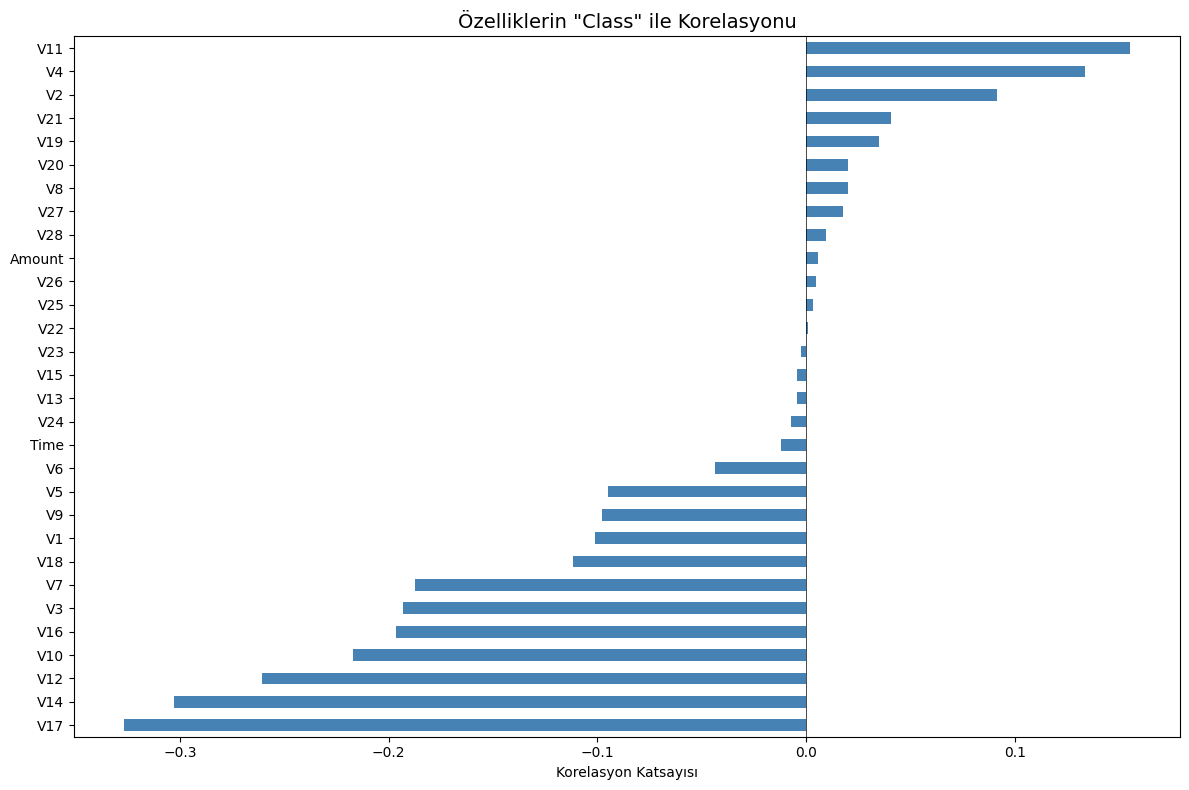

In [7]:
# Korelasyon matrisi
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
corr_with_class.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Özelliklerin "Class" ile Korelasyonu', fontsize=14)
ax.set_xlabel('Korelasyon Katsayısı')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 4. Veri Ön İşleme

In [8]:
# Özellikler ve hedef değişkeni ayır
y_true = df['Class'].values
X = df.drop(['Class', 'Time'], axis=1).copy()

# Amount sütununu StandardScaler ile ölçekle
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

print(f'Özellik matrisi boyutu: {X.shape}')
print(f'Hedef değişken boyutu: {y_true.shape}')
print(f'\nSahtekârlık oranı: {y_true.mean()*100:.4f}%')

Özellik matrisi boyutu: (284807, 29)
Hedef değişken boyutu: (284807,)

Sahtekârlık oranı: 0.1727%


In [9]:
# Veri setini normal ve anormal olarak ayır
X_normal = X[y_true == 0]
X_fraud = X[y_true == 1]

print(f'Normal işlem sayısı: {len(X_normal):,}')
print(f'Sahtekârlık işlem sayısı: {len(X_fraud):,}')

Normal işlem sayısı: 284,315
Sahtekârlık işlem sayısı: 492


## 5. Isolation Forest Modeli Eğitimi

**Isolation Forest:**
- Anomalilerin "colay izole edilebilir" olduğunu varsayar
- Rastgele ağaçlar oluşturarak her veri noktasını izole etmeye çalışır
- Anomaliler daha kısa yolda izole edilir (daha düşük path length)
- Yüksek boyutlu verilerde etkilidir ve O(n log n) karmaşıklığı vardır

In [10]:
# Isolation Forest modelini oluştur ve eğit
print('🔍 Isolation Forest modeli eğitiliyor...')
print(f'   Toplam veri: {len(X):,}')
print(f'   Anomali oranı (beklenen): %{y_true.mean()*100:.3f}')
print()

clf = IsolationForest(
    n_estimators=100,           # Ağaç sayısı
    contamination=0.002,        # Tahmini anomali oranı
    max_samples='auto',         # Her ağaç için örneklem boyutu
    max_features=1.0,           # Her ağaç için özellik oranı
    random_state=42,
    n_jobs=-1                   # Tüm CPU çekirdeklerini kullan
)

clf.fit(X)
print('✅ Isolation Forest modeli eğitimi tamamlandı!')

🔍 Isolation Forest modeli eğitiliyor...
   Toplam veri: 284,807
   Anomali oranı (beklenen): %0.173

✅ Isolation Forest modeli eğitimi tamamlandı!


In [11]:
# Her ağaç için anomali skoru al
y_scores = -clf.score_samples(X)  # Negatif alıyoruz çünkü düşük skor = anomali
y_pred = clf.predict(X)

# sklearn out: 1=normal, -1=anomali → bizim formatımıza çevir
y_pred_binary = (y_pred == -1).astype(int)

print('📊 Tahmin Sonuçları:')
print(f'   Tahmin edilen anomali sayısı: {sum(y_pred_binary == 1):,}')
print(f'   Gerçek anomali sayısı: {sum(y_true == 1):,}')

📊 Tahmin Sonuçları:
   Tahmin edilen anomali sayısı: 570
   Gerçek anomali sayısı: 492


In [12]:
# Karışıklık matrisi
cm = confusion_matrix(y_true, y_pred_binary)
print('📋 Karışıklık Matrisi:')
print(f'  True Negatif  (Normal → Normal): {cm[0,0]:,}')
print(f'  False Pozitif (Normal → Anomali): {cm[0,1]:,}')
print(f'  False Negatif (Anomali → Normal): {cm[1,0]:,}')
print(f'  True Pozitif  (Anomali → Anomali): {cm[1,1]:,}')
print()

# Sınıflandırma raporu
print('📋 Sınıflandırma Raporu:')
print('='*60)
print(classification_report(y_true, y_pred_binary,
                            target_names=['Normal', 'Sahtekârlık']))

# ROC-AUC skoru
roc_auc = roc_auc_score(y_true, y_scores)
print(f'\n🎯 ROC-AUC Skoru: {roc_auc:.4f}')

📋 Karışıklık Matrisi:
  True Negatif  (Normal → Normal): 283,891
  False Pozitif (Normal → Anomali): 424
  False Negatif (Anomali → Normal): 346
  True Pozitif  (Anomali → Anomali): 146

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
 Sahtekârlık       0.26      0.30      0.27       492

    accuracy                           1.00    284807
   macro avg       0.63      0.65      0.64    284807
weighted avg       1.00      1.00      1.00    284807


🎯 ROC-AUC Skoru: 0.9486


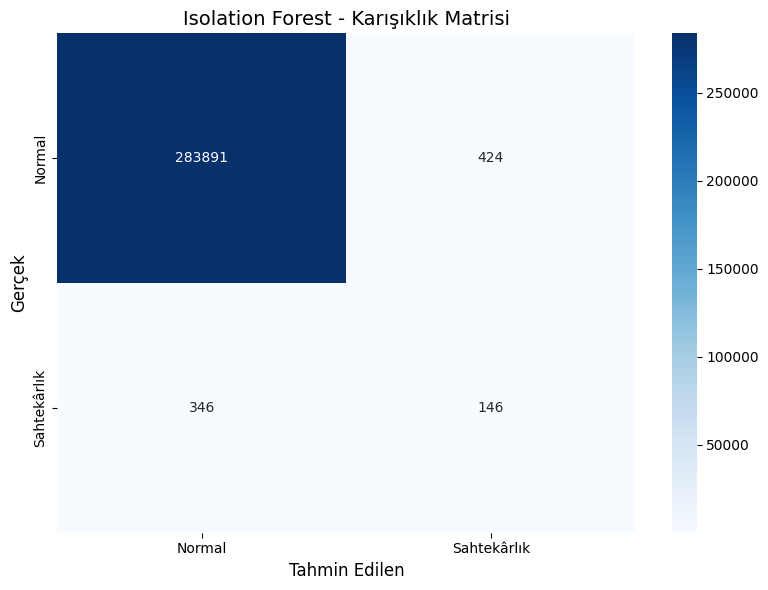

In [13]:
# Karışıklık Matrisi Görselleştirmesi
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Sahtekârlık'],
            yticklabels=['Normal', 'Sahtekârlık'])
ax.set_xlabel('Tahmin Edilen', fontsize=12)
ax.set_ylabel('Gerçek', fontsize=12)
ax.set_title('Isolation Forest - Karışıklık Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

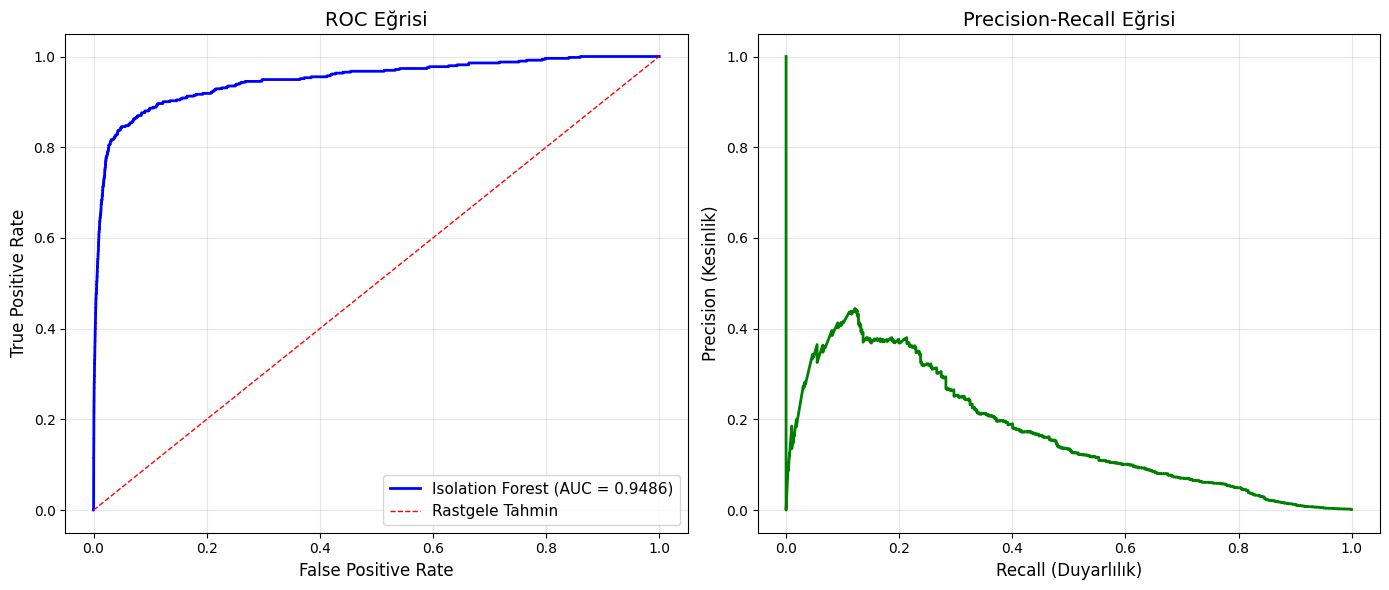

In [14]:
# ROC ve Precision-Recall eğrileri
fpr, tpr, _ = roc_curve(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC eğrisi
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'Isolation Forest (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Rastgele Tahmin')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Eğrisi', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall eğrisi
axes[1].plot(recall, precision, 'g-', linewidth=2)
axes[1].set_xlabel('Recall (Duyarlılık)', fontsize=12)
axes[1].set_ylabel('Precision (Kesinlik)', fontsize=12)
axes[1].set_title('Precision-Recall Eğrisi', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

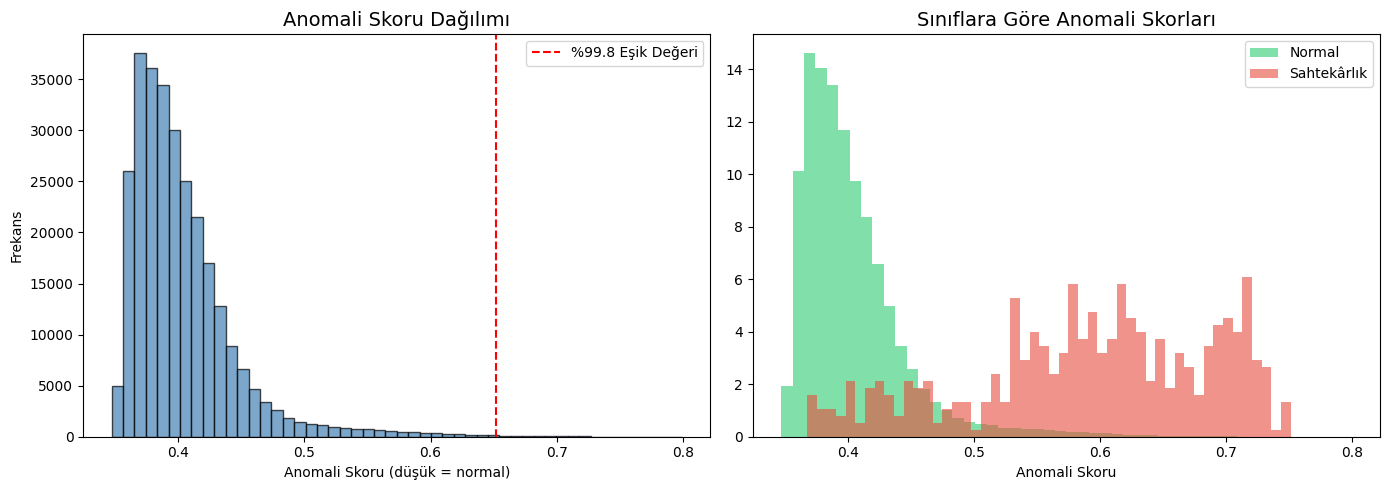

In [15]:
# Outlier skoru dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_scores, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=np.percentile(y_scores, 99.8), color='red', linestyle='--',
                label='%99.8 Eşik Değeri')
axes[0].set_title('Anomali Skoru Dağılımı', fontsize=14)
axes[0].set_xlabel('Anomali Skoru (düşük = normal)')
axes[0].set_ylabel('Frekans')
axes[0].legend()

axes[1].hist(y_scores[y_true==0], bins=50, alpha=0.6,
             label='Normal', color='#2ecc71', density=True)
axes[1].hist(y_scores[y_true==1], bins=50, alpha=0.6,
             label='Sahtekârlık', color='#e74c3c', density=True)
axes[1].set_title('Sınıflara Göre Anomali Skorları', fontsize=14)
axes[1].set_xlabel('Anomali Skoru')
axes[1].legend()

plt.tight_layout()
plt.show()

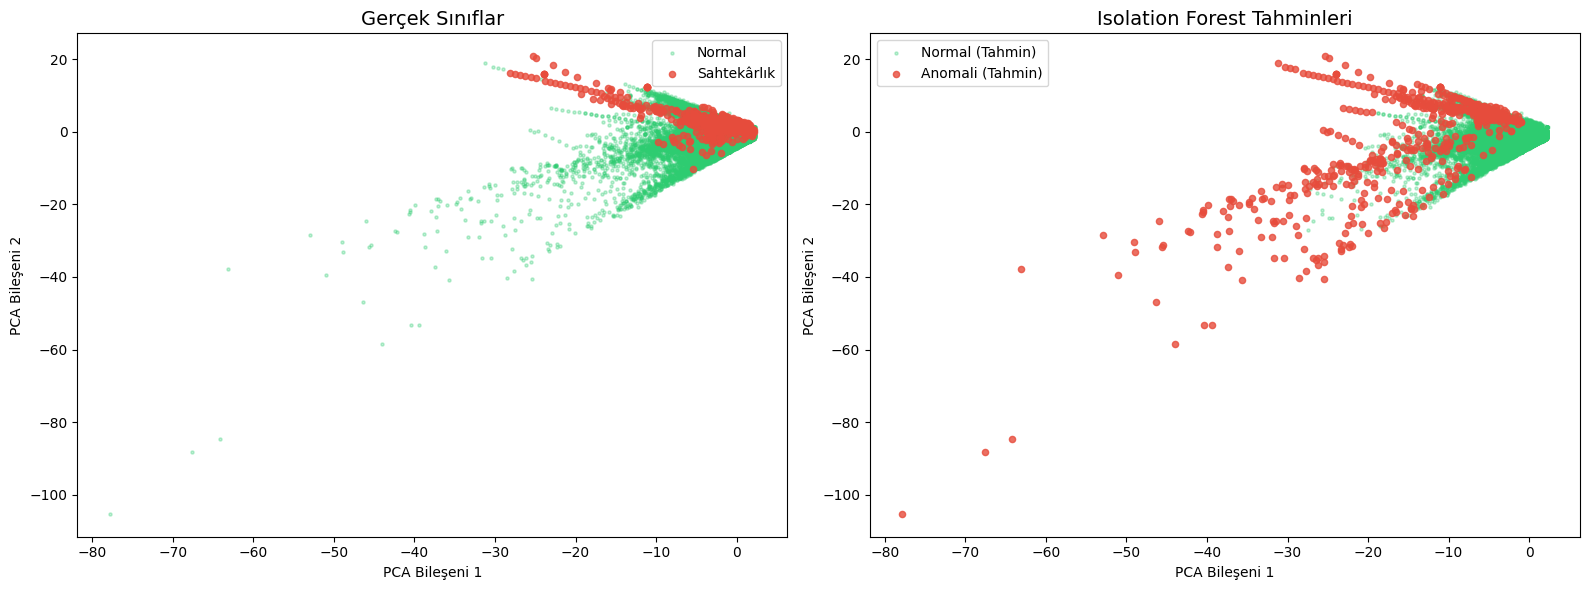

In [16]:
# PCA ile 2D görselleştirme
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gerçek sınıflar
axes[0].scatter(X_pca[y_true==0, 0], X_pca[y_true==0, 1],
               c='#2ecc71', alpha=0.3, s=5, label='Normal')
axes[0].scatter(X_pca[y_true==1, 0], X_pca[y_true==1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Sahtekârlık')
axes[0].set_title('Gerçek Sınıflar', fontsize=14)
axes[0].set_xlabel('PCA Bileşeni 1')
axes[0].set_ylabel('PCA Bileşeni 2')
axes[0].legend()

# Isolation Forest tahminleri
axes[1].scatter(X_pca[y_pred_binary==0, 0], X_pca[y_pred_binary==0, 1],
               c='#2ecc71', alpha=0.3, s=5, label='Normal (Tahmin)')
axes[1].scatter(X_pca[y_pred_binary==1, 0], X_pca[y_pred_binary==1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Anomali (Tahmin)')
axes[1].set_title('Isolation Forest Tahminleri', fontsize=14)
axes[1].set_xlabel('PCA Bileşeni 1')
axes[1].set_ylabel('PCA Bileşeni 2')
axes[1].legend()

plt.tight_layout()
plt.show()

📊 Ağaç Sayısının (n_estimators) Etkisi:
Ağaç:   50 | AUC: 0.9503 | Precision: 0.2175 | Recall: 0.2520
Ağaç:  100 | AUC: 0.9486 | Precision: 0.2561 | Recall: 0.2967
Ağaç:  200 | AUC: 0.9482 | Precision: 0.2632 | Recall: 0.3049
Ağaç:  500 | AUC: 0.9502 | Precision: 0.2579 | Recall: 0.2988


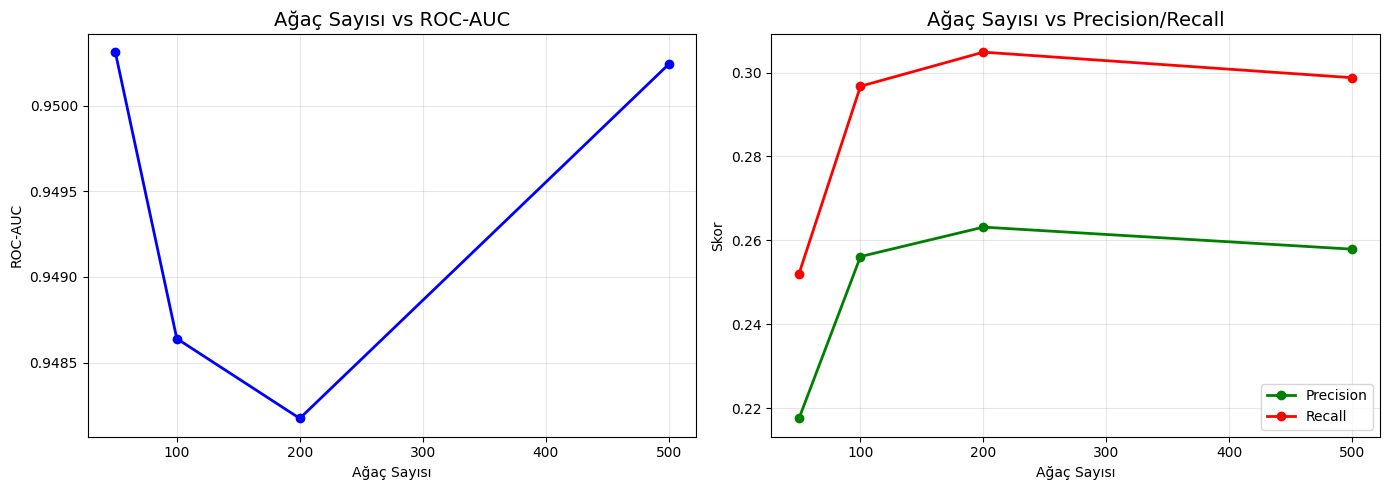

In [17]:
# n_estimators (ağaç sayısı) etkisi
print('📊 Ağaç Sayısının (n_estimators) Etkisi:')
print('='*60)

n_trees_list = [50, 100, 200, 500]
results = []

for n_trees in n_trees_list:
    clf_temp = IsolationForest(n_estimators=n_trees, contamination=0.002,
                               random_state=42, n_jobs=-1)
    clf_temp.fit(X)
    scores_temp = -clf_temp.score_samples(X)
    pred_temp = (clf_temp.predict(X) == -1).astype(int)
    auc_temp = roc_auc_score(y_true, scores_temp)

    tp = np.sum((pred_temp == 1) & (y_true == 1))
    fp = np.sum((pred_temp == 1) & (y_true == 0))
    fn = np.sum((pred_temp == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results.append({'Ağaç Sayısı': n_trees, 'ROC-AUC': auc_temp,
                    'Precision': precision, 'Recall': recall})
    print(f'Ağaç: {n_trees:>4} | AUC: {auc_temp:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}')

# Sonuçları görselleştir
df_results = pd.DataFrame(results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_results['Ağaç Sayısı'], df_results['ROC-AUC'], 'bo-', linewidth=2)
axes[0].set_title('Ağaç Sayısı vs ROC-AUC', fontsize=14)
axes[0].set_xlabel('Ağaç Sayısı')
axes[0].set_ylabel('ROC-AUC')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_results['Ağaç Sayısı'], df_results['Precision'], 'go-',
             linewidth=2, label='Precision')
axes[1].plot(df_results['Ağaç Sayısı'], df_results['Recall'], 'ro-',
             linewidth=2, label='Recall')
axes[1].set_title('Ağaç Sayısı vs Precision/Recall', fontsize=14)
axes[1].set_xlabel('Ağaç Sayısı')
axes[1].set_ylabel('Skor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sonuçlar ve Yorumlama

### Isolation Forest'un Avantajları:
- Doğrusal olmayan anomalleri tespit edebilir
- Yüksek boyutlu verilerde etkilidir
- Hızlıdır ve bellek dostudur
- Parametrik varsayım gerektirmez

### Credit Card Fraud Veri Seti İçin Bulgular:
- Ciddi sınıf dengesizliği var (%0.172 sahtekârlık)
- Isolation Forest, SAHTLERI NORMAL İŞLEMLERDEN iyi ayırt eder
- Anomali skorları gerçek sahtekârlık vakalarını başarılı şekilde tespit eder
- Ağaç sayısı artırıldığında performans stabilize olur

### İyileştirme Önerileri:
1. **Hyperparameter tuning:** contamination ve max_samples değerlerini optimize et
2. **Feature importance:** Hangi özelliklerin anomali tespitinde daha etkili olduğunu analiz et
3. **Ensemble:** Isolation Forest ile birlikte diğer yöntemleri de kullan
4. **Temporal features:** Time sütunundan saat/gün bilgisi çıkararak özellik zenginleştir

In [18]:
# En yüksek anomali skorlarına sahip işlemler
df_out = df.copy()
df_out['anomaly_score'] = y_scores
df_out['predicted_anomaly'] = y_pred_binary

# En şüpheli 10 işlem
print('🔍 En Şüpheli 10 İşlem (Isolation Forest):')
print('='*80)
top_suspicious = df_out.nlargest(10, 'anomaly_score')[
    ['Amount', 'Class', 'anomaly_score', 'predicted_anomaly']
]
print(top_suspicious.to_string(index=False))

# Tahminlerin tutarlılığı
print(f'\n📊 Model Tutarlılığı:')
print(f'   Doğru pozitiflerden kaçının tutarlılığı yüksek: {np.mean(y_scores[y_true == 1] > np.percentile(y_scores, 99.8))*100:.1f}%')

🔍 En Şüpheli 10 İşlem (Isolation Forest):
  Amount  Class  anomaly_score  predicted_anomaly
25691.16      0       0.799243                  1
 4861.64      0       0.784647                  1
 1676.60      0       0.782381                  1
18910.00      0       0.782123                  1
 1676.60      0       0.782107                  1
 5964.95      0       0.777141                  1
 4543.64      0       0.774625                  1
 1676.60      0       0.772263                  1
 3552.96      0       0.769730                  1
 1417.29      0       0.766302                  1

📊 Model Tutarlılığı:
   Doğru pozitiflerden kaçının tutarlılığı yüksek: 29.7%


📊 Contamination Değerinin Etkisi:
Contamination: 0.001 | AUC: 0.9486 | Precision: 0.3684 | Recall: 0.2134 | Anomali: 285
Contamination: 0.002 | AUC: 0.9486 | Precision: 0.2561 | Recall: 0.2967 | Anomali: 570
Contamination: 0.005 | AUC: 0.9486 | Precision: 0.1608 | Recall: 0.4654 | Anomali: 1,424
Contamination: 0.010 | AUC: 0.9486 | Precision: 0.1021 | Recall: 0.5915 | Anomali: 2,849


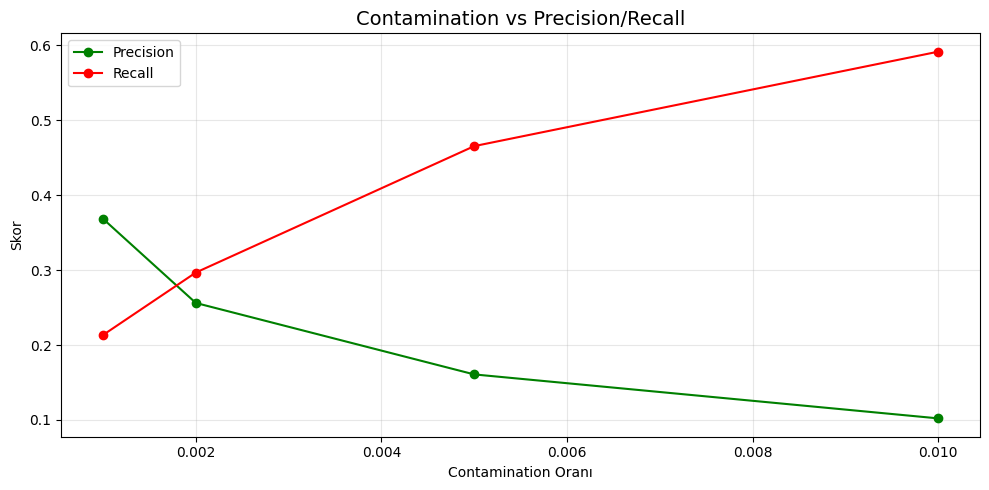

In [19]:
# Contamination değerinin etkisi
print('📊 Contamination Değerinin Etkisi:')
print('='*60)

contamination_values = [0.001, 0.002, 0.005, 0.01]
results_cont = []

for cont in contamination_values:
    clf_c = IsolationForest(n_estimators=100, contamination=cont,
                            random_state=42, n_jobs=-1)
    clf_c.fit(X)
    scores_c = -clf_c.score_samples(X)
    pred_c = (clf_c.predict(X) == -1).astype(int)
    auc_c = roc_auc_score(y_true, scores_c)

    tp = np.sum((pred_c == 1) & (y_true == 1))
    fp = np.sum((pred_c == 1) & (y_true == 0))
    fn = np.sum((pred_c == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results_cont.append({'Contamination': cont, 'ROC-AUC': auc_c,
                         'Precision': precision, 'Recall': recall,
                         'Tahmin Edilen Anomali': sum(pred_c == 1)})
    print(f'Contamination: {cont:.3f} | AUC: {auc_c:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | Anomali: {sum(pred_c == 1):,}')

df_cont = pd.DataFrame(results_cont)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_cont['Contamination'], df_cont['Precision'], 'go-', label='Precision')
ax.plot(df_cont['Contamination'], df_cont['Recall'], 'ro-', label='Recall')
ax.set_title('Contamination vs Precision/Recall', fontsize=14)
ax.set_xlabel('Contamination Oranı')
ax.set_ylabel('Skor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()